# Visualisatie van classificatie met een DecisionTreeClassifier

In dit notebook:
1. Genereren we een 2D-toy dataset.
2. Trainen we een `DecisionTreeClassifier`.
3. Visualiseren we de beslissingsgrenzen en de decision tree zelf.

Je kunt dit notebook als basis gebruiken om met andere instellingen en datasets te experimenteren.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap


## 1. Dataset genereren

In [2]:
# Stel een random seed in voor reproduceerbaarheid
RANDOM_STATE = 42

# Genereer een niet-lineaire 2D dataset (maantjes)
X, y = make_moons(n_samples=400, noise=0.25, random_state=RANDOM_STATE)

print(f'Vorm van X: {X.shape}')
print(f'Vorm van y: {y.shape}')

Vorm van X: (400, 2)
Vorm van y: (400,)


## 2. Train-test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

print('Train set:', X_train.shape, y_train.shape)
print('Test set :', X_test.shape, y_test.shape)

Train set: (280, 2) (280,)
Test set : (120, 2) (120,)


## 3. DecisionTreeClassifier trainen

In [8]:
# Maak en train het model
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
tree_clf.fit(X_train, y_train)

train_score = tree_clf.score(X_train, y_train)
test_score = tree_clf.score(X_test, y_test)

print(f'Train accuracy: {train_score:.3f}')
print(f'Test accuracy : {test_score:.3f}')

Train accuracy: 0.904
Test accuracy : 0.900


## 4. Beslissingsgrenzen visualiseren

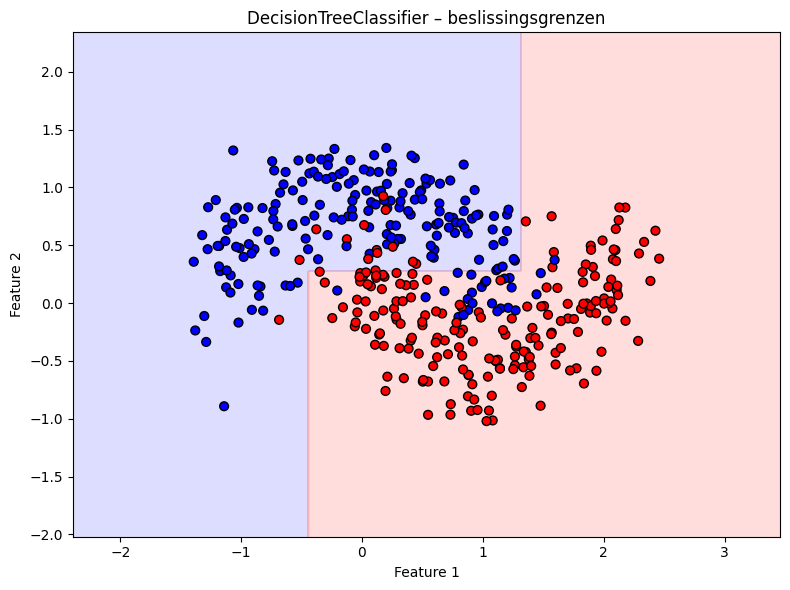

In [9]:
def plot_decision_regions(model, X, y, title="Decision regions"):
    # Maak een grid over de feature space
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Voorspel de klasse voor elk punt in de grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Kleurkaart voor 2 klassen
    cmap_background = ListedColormap(['#AAAAFF', '#FFAAAA'])
    cmap_points = ListedColormap(['#0000FF', '#FF0000'])

    plt.figure(figsize=(8, 6))
    # Teken beslissingsvlak
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_background)

    # Teken trainpunten
    plt.scatter(
        X[:, 0], X[:, 1], c=y,
        cmap=cmap_points, edgecolor='k', s=40
    )

    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.tight_layout()
    plt.show()

# Visualiseer de beslissingsgrenzen op de volledige dataset
plot_decision_regions(tree_clf, X, y, title='DecisionTreeClassifier – beslissingsgrenzen')

## 5. De decision tree visualiseren

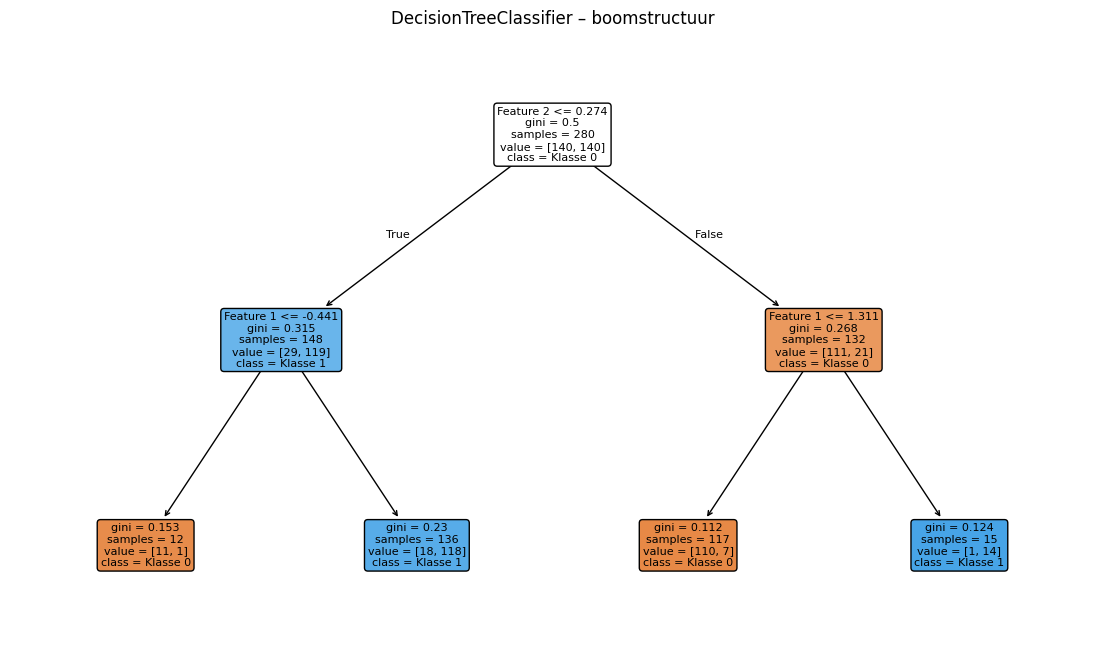

In [10]:
plt.figure(figsize=(14, 8))
plot_tree(
    tree_clf,
    filled=True,
    feature_names=['Feature 1', 'Feature 2'],
    class_names=['Klasse 0', 'Klasse 1'],
    rounded=True,
    fontsize=8
)
plt.title('DecisionTreeClassifier – boomstructuur')
plt.show()

## 6. Experimenteer zelf
Pas hieronder de hyperparameters aan, zoals `max_depth`, `min_samples_split` of `criterion` ('gini' of 'entropy'), en draai de cellen opnieuw om te zien wat er verandert.

Train accuracy (experiment): 0.9035714285714286
Test accuracy  (experiment): 0.9


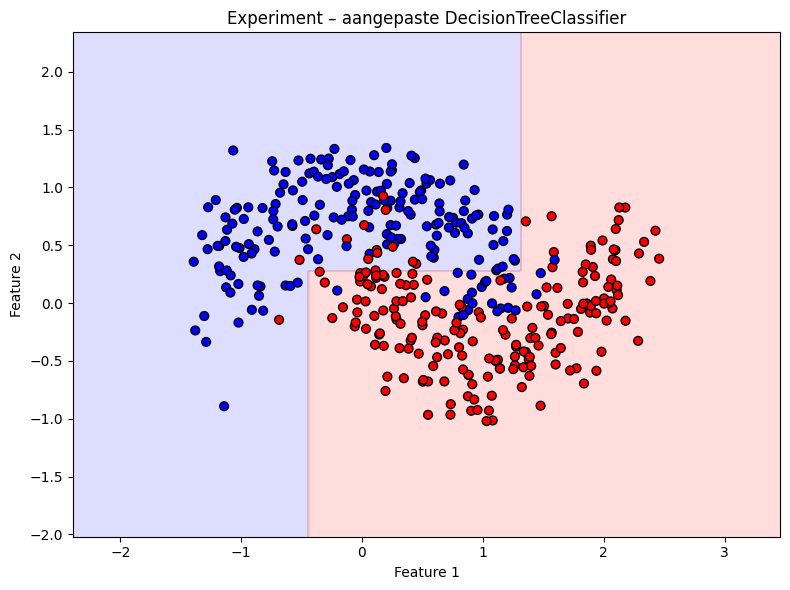

In [11]:
# Probeer andere instellingen
experiment_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=4,
    criterion='gini',
    random_state=RANDOM_STATE
)
experiment_tree.fit(X_train, y_train)

print('Train accuracy (experiment):', experiment_tree.score(X_train, y_train))
print('Test accuracy  (experiment):', experiment_tree.score(X_test, y_test))

plot_decision_regions(experiment_tree, X, y, title='Experiment – aangepaste DecisionTreeClassifier')